In [ ]:
---
title: alksdjfals
format: pdf
---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from numpy.random import uniform, normal

In [3]:
# questão 1

f_x = lambda x: 5 * x**2 * (1 - x)
M = []
X_simulated = []
y_simulated = []

N = 0
sum_irreducible = 0

np.random.seed(0)
grid = np.linspace(-2, 2, 100)

for sample in range(500):
    X_train = uniform(-2, 2, 100)
    y_train = f_x(X_train) + normal(0, 1, 100)

    N += len(X_train)
    sum_irreducible += np.sum((y_train - f_x(X_train)) ** 2)

    for degree in range(1, 16):
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
        f_hat = LinearRegression(fit_intercept=False).fit(X=X_train_poly, y=y_train)
        X_train_poly_grid = poly.transform(grid.reshape(-1, 1))

        preds = f_hat.predict(X_train_poly_grid)

        for i, pred in enumerate(preds):
            M.append(
                {
                    "sample": sample,
                    "degree": degree,
                    "f_hat": f_hat,
                    "x_grid_id": i,
                    "prediction_grid": pred,
                }
            )

fitted_models = pd.DataFrame(M)\
    .assign(
        f_bar_hat=lambda x: x.groupby(["degree", "x_grid_id"])["prediction_grid"].transform("mean"),
        bias = lambda x: (x.f_bar_hat - f_x(grid[x.x_grid_id])),
        var_hat=lambda x: x.groupby(["degree", "x_grid_id"]).prediction_grid.transform(lambda y: y.var(ddof=0)),
        sigma2_hat=sum_irreducible / N,
        total_error=lambda x: x.bias**2 + x.var_hat + x.sigma2_hat
    )

In [4]:
fitted_models.query("total_error == total_error.min()")

,sample,degree,f_hat,x_grid_id,prediction_grid,f_bar_hat,bias,var_hat,sigma2_hat,total_error
248,0,3,LinearRegression(fit_intercept=False),48,0.372785,0.017878,-0.001601,0.025708,0.996501,1.022211
1748,1,3,LinearRegression(fit_intercept=False),48,-0.019608,0.017878,-0.001601,0.025708,0.996501,1.022211
3248,2,3,LinearRegression(fit_intercept=False),48,-0.089042,0.017878,-0.001601,0.025708,0.996501,1.022211
4748,3,3,LinearRegression(fit_intercept=False),48,-0.041954,0.017878,-0.001601,0.025708,0.996501,1.022211
6248,4,3,LinearRegression(fit_intercept=False),48,-0.063831,0.017878,-0.001601,0.025708,0.996501,1.022211
...,...,...,...,...,...,...,...,...,...,...
742748,495,3,LinearRegression(fit_intercept=False),48,-0.025007,0.017878,-0.001601,0.025708,0.996501,1.022211
744248,496,3,LinearRegression(fit_intercept=False),48,0.160326,0.017878,-0.001601,0.025708,0.996501,1.022211
745748,497,3,LinearRegression(fit_intercept=False),48,-0.076784,0.017878,-0.001601,0.025708,0.996501,1.022211
747248,498,3,LinearRegression(fit_intercept=False),48,-0.023167,0.017878,-0.001601,0.025708,0.996501,1.022211


Text(0, 0.5, 'error')

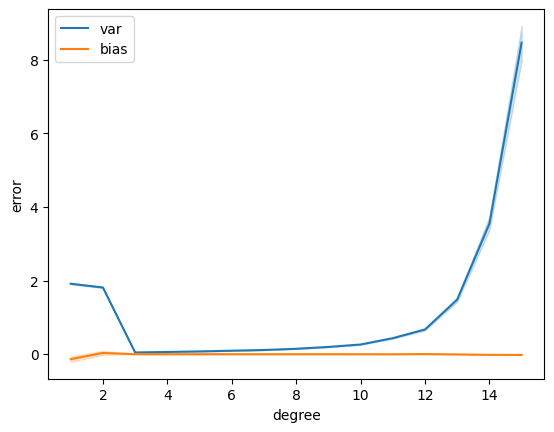

In [5]:
# sns.lineplot(
#     fitted_models,
#     x="degree",
#     y="total_error",
#     label="total_error"
# )

sns.lineplot(
    fitted_models,
    x="degree",
    y="var_hat",
    label="var"
)

sns.lineplot(
    fitted_models,
    x="degree",
    y="bias",
    label="bias"
)

plt.ylabel("error")

In [23]:
# questão 2

n = 1_000
x = uniform(-2, 2, n)
y = f_x(x) + normal(0, 1, n)

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=.2, random_state=42)
x_train, x_cal, y_train, y_cal = train_test_split(x_temp, y_temp, test_size=.25, random_state=42)

x_train = x_train.reshape(-1, 1)
x_cal = x_cal.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

model_metric = []
for degree in [1, 2, 3, 5, 10]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(x_train)
    fit_model_train = LinearRegression(fit_intercept=False).fit(X=X_train_poly, y=y_train)

    X_cal_poly = poly.transform(x_cal)
    X_test_poly = poly.transform(x_test)

    preds_train = fit_model_train.predict(X=X_train_poly)
    preds_cal = fit_model_train.predict(X=X_cal_poly)
    preds_test = fit_model_train.predict(X_test_poly)

    model_metric.append(
        {
            "degree": degree,
            "rmse_train_error": root_mean_squared_error(y_pred=preds_train, y_true=y_train),
            "rmse_cal_error": root_mean_squared_error(y_pred=preds_cal, y_true=y_cal),
            "rmse_test_error": root_mean_squared_error(y_pred=preds_test, y_true=y_test)
        }
    )

model_metric = pd.DataFrame(model_metric)

In [24]:
model_metric

,degree,rmse_train_error,rmse_cal_error,rmse_test_error
0,1,8.538802,9.424197,7.737336
1,2,6.151821,6.459924,5.774781
2,3,0.972899,0.952203,0.946018
3,5,0.970708,0.956691,0.954439
4,10,0.967942,0.962828,0.958374


In [30]:
## questão 3

cv = KFold(random_state=42, n_splits=5, shuffle=True)
fold_metrics = []

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=42)

x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

for fold, (idx_train, idx_val) in enumerate(cv.split(x_train), start=1):
    x_fold_train = x_train[idx_train]
    y_fold_train = y_train[idx_train]

    x_fold_val = x_train[idx_val]
    y_fold_val = y_train[idx_val]

    for degree in range(100):
        poly = PolynomialFeatures(degree=degree)
        x_fold_train_poly = poly.fit_transform(x_fold_train)

        fit_model_train = LinearRegression(fit_intercept=False).fit(X=x_fold_train_poly, y=y_fold_train)
        preds_train = fit_model_train.predict(x_fold_train_poly)
        preds_val = fit_model_train.predict(X=poly.transform(x_fold_val))

        poly_all_data = PolynomialFeatures(degree=degree)
        X_train_all_data_poly = poly_all_data.fit_transform(x_train)
        fit_model_all_data = LinearRegression(fit_intercept=False).fit(X=X_train_all_data_poly, y=y_train)

        fold_metrics.append(
            {
                "fold": fold,
                "degree": degree,
                "rmse_train_fold_error": root_mean_squared_error(y_pred=preds_train, y_true=y_fold_train),
                "rmse_val_fold_error": root_mean_squared_error(y_pred=preds_val, y_true=y_fold_val),
                "rmse_train_all_data_error": root_mean_squared_error(y_pred=fit_model_all_data.predict(X_train_all_data_poly), y_true=y_train),
                "rmse_test_all_data_error": root_mean_squared_error(
                    y_pred=fit_model_all_data.predict(
                        poly_all_data.transform(x_test)
                    ),
                    y_true=y_test),
            }
        )

fold_metrics = pd.DataFrame(fold_metrics)\
    .assign(
        rmse_train_fold_error=lambda x: x.groupby("degree").rmse_train_fold_error.transform("mean"),
        rmse_val_fold_error=lambda x: x.groupby("degree").rmse_val_fold_error.transform("mean"),
        rmse_train_all_data_error=lambda x: x.groupby("degree").rmse_train_all_data_error.transform("mean"),
        rmse_test_all_data_error=lambda x: x.groupby("degree").rmse_test_all_data_error.transform("mean"),
    ).drop_duplicates(subset=["degree"])

In [31]:
fold_metrics.query("rmse_val_fold_error == rmse_val_fold_error.min()")

,fold,degree,rmse_train_fold_error,rmse_val_fold_error,rmse_train_all_data_error,rmse_test_all_data_error
3,1,3,0.973271,0.978375,0.974075,0.935355


In [32]:
fold_metrics.query("rmse_test_all_data_error == rmse_test_all_data_error.min()")

,fold,degree,rmse_train_fold_error,rmse_val_fold_error,rmse_train_all_data_error,rmse_test_all_data_error
4,1,4,0.972934,0.97987,0.973943,0.934822
